# Figures  
- Contains figures according to manuscripts

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
%reload_ext autoreload
%autoreload 2

import matplotlib.patches as patches
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from scipy.stats import spearmanr, linregress
import matplotlib.gridspec as gridspec
import pwlf

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


## Figure 2

In [77]:
# load data
df = reader.data_read_bz2("raw/FN/itr_200.bz2")

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

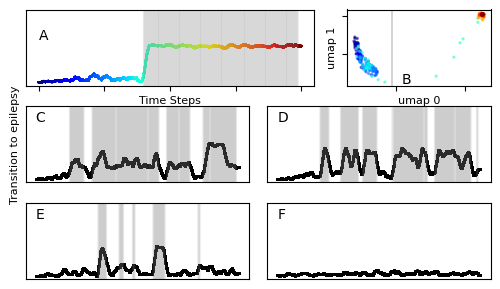

In [ ]:
fig = plt.figure(figsize=([6,3.5]))

gs = gridspec.GridSpec(12, 12)
# gs.update(wspace = 1.5, hspace = 0.3)

ax1 = plt.subplot(gs[0:4, 0:8])
# itr 136 of FN
_data = df[39].rolling(800, center=True).mean().ffill().bfill()

cmap = "jet"
with open("../../data/umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)
chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)
# Train StandardScaler, Z score normalising values

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary

sep = -0.6
plt.subplots_adjust(hspace=6, wspace=0.8)
ax1.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax1.axvline(l, c="gray", alpha=0.1)
# ax1.set_ylabel("Global Order")
ax1.set_xlabel("Time Steps",fontsize=8)
# ax1.set_xlabel('Time Steps')
# ax1.xaxis.set_visible(False)
# ax1.yaxis.set_visible(False)
ax1.set_ylim([0, 1])
ax1.text(0, 0.6, "A")
ax1.yaxis.set_visible(False)
pos = ax1.get_position()
ax1.set_position([pos.x0, pos.y0, pos.width * 0.95, pos.height])



ax2 = plt.subplot(gs[0:4, 8:12])
# umap
ax2.scatter(
    embedding[:, 0], embedding[:, 1], s=2, c=range(len(chunks)), alpha=0.5, cmap=cmap
)
ax2.set_xlabel("umap 0",fontsize=8)
ax2.set_ylabel("umap 1",fontsize=8)
ax2.text(0.8, 1, "B")
ax2.axvline(sep, c="k", lw=0.25)
# ax2.xaxis.set_visible(False)
# ax2.yaxis.set_visible(False)
# ax1.set_ylabel('ylabel', labelpad = 0, fontsize = 12)



ax3 = plt.subplot(gs[4:8, 0:6])
# ax2.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax3.xaxis.set_visible(False)
# ax3.yaxis.set_visible(False)
_data = df[136].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax3.scatter(_data.index, _data, c='black', s=1)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax3.axvline(l, c="gray", alpha=0.1)
ax3.set_ylabel('Transition to epilepsy',fontsize=8)
ax3.set_ylim([0, 1])
ax3.text(0, 0.8, "C")
# ax3.yaxis.set_visible(False)
ax3.yaxis.set_ticks([])

ax4 = plt.subplot(gs[4:8, 6:12], sharex=ax3, sharey=ax3)
# ax3.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)
_data = df[193].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax4.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax4.axvline(l, c="gray", alpha=0.1)
ax4.set_ylim([0, 1])
ax4.text(0, 0.8, "D")

ax5 = plt.subplot(gs[8:12, 0:6], sharex=ax3, sharey=ax3)
# ax4.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax5.xaxis.set_visible(False)
ax5.yaxis.set_visible(False)
_data = df[145].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax5.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax5.axvline(l, c="gray", alpha=0.1)
ax5.set_ylim([0, 1])
ax5.text(0, 0.8, "E")

ax6 = plt.subplot(gs[8:12, 6:12], sharex=ax3, sharey=ax3)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
_data = df[1].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax6.scatter(_data.index, _data, c='black', s=0.5)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax6.axvline(l, c="gray", alpha=0.1)
ax6.set_ylim([0, 1])
# ax6.set_xlabel("time steps")
ax6.text(0, 0.8, "F")

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)


plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

# plt.setp(ax3.get_yticklabels(),visible=False)
plt.ylabel('Transistion to epeilpesy', fontsize=8)

fig.align_labels()

fig.set_layout_engine(layout="tight")
# plt.savefig('fig2_final.pdf',format='pdf')
# plt.savefig('../../data/results/figures/fig2_final.svg')
# plt.savefig('../../data/results/figures/fig2_final.pdf',format='pdf')

# Figure 3

#### Read data from folder  
Reference notebook: "Analyse Calculate Final Params.ipynb"


In [3]:
# defining dictionaries for each parameter
# storing both partial and full transition data
# store standard deviation and manWhitney U test values

num_trans = {}
n_p = []
n_p_s = []
n_f = []
n_f_s = []

trans_time = {}
t_p = []
t_p_s = []
t_f = []
t_f_s = []
t_p_mw = []
t_f_mw = []

fp_time = {}
f_p = []
f_p_s = []
f_f = []
f_f_s = []
f_p_mw = []
f_f_mw = []

sync_time = {}
s_p = []
s_p_s = []
s_f = []
s_f_s = []
s_p_mw = []
s_f_mw = []

cov = {}
cov_p = []
cov_p_s = []
cov_f = []
cov_f_s = []
cov_p_mw = []
cov_f_mw = []

# node_label=['PERI','ENTI','ORB','RE','BLA','PIR','MOp','MOs','LHA','MOB','LSc','MRN']
# getting networks in ascending order
network_asc = [
    "fn",
    "mob",
    "lsc",
    "orb",
    "pir",
    "bla",
    "mrn",
    "re",
    "enti",
    "peri",
    "mos",
    "lha",
    "mop",
]
fn_data = reader.data_read_pkl("results/calculate_final_params/final_fn.pkl")

# uses manwhitney u test and stores p value
for nw in network_asc:
    params = reader.data_read_pkl(f"results/calculate_final_params/final_{nw}.pkl")
    # store number of transition
    n_p.append(params[0]["n_part"])
    n_f.append(params[0]["n_full"])
    n_p_s.append(np.sqrt(params[0]["n_part"]))
    n_f_s.append(np.sqrt(params[0]["n_full"]))

    # store transition time
    t_p_s.append(np.std(params[1]["t_t"]) / np.sqrt(len(params[1]["t_t"])))
    t_f_s.append(np.std(params[2]["t_t"]) / np.sqrt(len(params[2]["t_t"])))

    t_p.append(np.mean(params[1]["t_t"]))
    _, mw = mannwhitneyu(fn_data[1]["t_t"], params[1]["t_t"])
    t_p_mw.append(mw)
    t_f.append(np.mean(params[2]["t_t"]))
    _, mw = mannwhitneyu(fn_data[2]["t_t"], params[2]["t_t"])
    t_f_mw.append(mw)

    # store first passage time
    f_p_s.append(np.std(params[1]["fp_t"]) / np.sqrt(len(params[1]["fp_t"])))
    f_f_s.append(np.std(params[2]["fp_t"]) / np.sqrt(len(params[2]["fp_t"])))

    f_p.append(np.mean(params[1]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[1]["fp_t"], params[1]["fp_t"])
    f_p_mw.append(mw)
    f_f.append(np.mean(params[2]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[2]["fp_t"], params[2]["fp_t"])
    f_f_mw.append(mw)

    # Store sync time
    s_p_s.append(np.std(params[1]["s_t"]) / np.sqrt(len(params[1]["s_t"])))
    s_f_s.append(np.std(params[2]["s_t"]) / np.sqrt(len(params[2]["s_t"])))

    s_p.append(np.mean(params[1]["s_t"]))
    _, mw = mannwhitneyu(fn_data[1]["s_t"], params[1]["s_t"])
    s_p_mw.append(mw)
    s_f.append(np.mean(params[2]["s_t"]))
    _, mw = mannwhitneyu(fn_data[2]["s_t"], params[2]["s_t"])
    s_f_mw.append(mw)

    # store coverage
    # removing zero coverage values from partial transitions as they might seep due to very small values
    cov_part=params[1]["cov"]
    cov_part=[x for x in cov_part if x>0]
    cov_p_s.append(np.std(cov_part) / np.sqrt(len(cov_part)))
    cov_f_s.append(np.std(params[2]["cov"]) / np.sqrt(len(params[2]["cov"])))

    cov_p.append(np.mean(cov_part))
    fn_part_cov=[x for x in fn_data[1]["cov"] if x>0]
    _, mw = mannwhitneyu(fn_part_cov, cov_part)
    cov_p_mw.append(mw)
    cov_f.append(np.mean(params[2]["cov"]))
    _, mw = mannwhitneyu(fn_data[2]["cov"], params[2]["cov"])
    cov_f_mw.append(mw)

num_trans = {"n_p": n_p, "n_f": n_f, "n_p_s": n_p_s, "n_f_s": n_f_s}
trans_time = {
    "t_p": t_p,
    "t_f": t_f,
    "t_p_s": t_p_s,
    "t_f_s": t_f_s,
    "t_p_mw": t_p_mw,
    "t_f_mw": t_f_mw,
}
fp_time = {
    "f_p": f_p,
    "f_f": f_f,
    "f_p_s": f_p_s,
    "f_f_s": f_f_s,
    "f_p_mw": f_p_mw,
    "f_f_mw": f_f_mw,
}

sync_time = {
    "s_p": s_p,
    "s_f": s_f,
    "s_p_s": s_p_s,
    "s_f_s": s_f_s,
    "s_p_mw": s_p_mw,
    "s_f_mw": s_f_mw,
}

cov = {
    "cov_p": cov_p,
    "cov_f": cov_f,
    "cov_p_s": cov_p_s,
    "cov_f_s": cov_f_s,
    "cov_p_mw": cov_p_mw,
    "cov_f_mw": cov_f_mw,
}

In [4]:
a = ["num_trans"] * 2
b = ["trans_time"] * 6
c = ["fp_time"] * 6
d = ["sync_time"] * 6
e = ["cov"] * 6
upper_head = a + b + c + d + e

f = ["part", "full"]
g = ["part", "part_s", "part_mw", "full_mw", "full", "full_s"] * 4
lower_head = f + g

header = [upper_head, lower_head]
data = {
    ("num_trans", "part"): num_trans["n_p"],
    ("num_trans", "full"): num_trans["n_f"],
    ("num_trans", "part_s"): num_trans["n_p_s"],
    ("num_trans", "full_s"): num_trans["n_f_s"],
    ("trans_time", "part"): trans_time["t_p"],
    ("trans_time", "part_s"): trans_time["t_p_s"],
    ("trans_time", "part_mw"): trans_time["t_p_mw"],
    ("trans_time", "full"): trans_time["t_f"],
    ("trans_time", "full_s"): trans_time["t_f_s"],
    ("trans_time", "full_mw"): trans_time["t_p_mw"],
    ("fp_time", "part"): fp_time["f_p"],
    ("fp_time", "part_s"): fp_time["f_p_s"],
    ("fp_time", "part_mw"): fp_time["f_p_mw"],
    ("fp_time", "full"): fp_time["f_f"],
    ("fp_time", "full_s"): fp_time["f_f_s"],
    ("fp_time", "full_mw"): fp_time["f_p_mw"],
    ("sync_time", "part"): sync_time["s_p"],
    ("sync_time", "part_s"): sync_time["s_p_s"],
    ("sync_time", "part_mw"): sync_time["s_p_mw"],
    ("sync_time", "full"): sync_time["s_f"],
    ("sync_time", "full_s"): sync_time["s_f_s"],
    ("sync_time", "full_mw"): sync_time["s_p_mw"],
    ("cov", "part"): cov["cov_p"],
    ("cov", "part_s"): cov["cov_p_s"],
    ("cov", "part_mw"): cov["cov_p_mw"],
    ("cov", "full"): cov["cov_f"],
    ("cov", "full_s"): cov["cov_f_s"],
    ("cov", "full_mw"): cov["cov_f_mw"],
}

df_data = pd.DataFrame(data, index=network_asc)
df_data

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  0.945461   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  0.865168   
orb        136   94  11.661904   9.695360  53.057721  1.124891  0.157965   
pir        110   67  10.488088   8.185353  54.763636  1.241981  0.522551   
bla        107   51  10.344080   7.141428  54.188318  1.117801  0.985780   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  0.254302   
re         200   92  14.142136   9.591663  54.124500  0.763217  0.836102   
enti       151   57  12.288206   7.549834  53.687417  0.960022  0.481269   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.010906   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.040213   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.041488   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.036977   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  0.945461  ...  0.104380  351.034483  47.294445   
lsc   79.419588  1.289129  0.865168  ...  0.986182  311.785714  68.102203   
orb   82.572340  1.616342  0.157965  ...  0.960917  347.413793  32.158404   
pir   80.195522  1.615760  0.522551  ...  0.040085  399.047619  67.131559   
bla   80.609804  1.689315  0.985780  ...  0.610470  230.625000  28.823784   
mrn   78.601899  1.529340  0.254302  ...  0.791234  407.600000  58.272546   
re    77.778261  1.304602  0.836102  ...  0.504608  487.000000  70.648425   
enti  76.766667  1.499051  0.481269  ...  0.410884  399.722222  54.870038   
peri  79.453191  1.495899  0.010906  ...  0.006671  253.333333  28.349668   
mos   85.559524  2.795582  0.040213  ...  0.324357  268.125000  29.287603   
lha   78.384545  1.645938  0.041488  ...  0.013377  358.000000  83.694683   
mop   78.736111  1.935845  0.036977  ...  0.927616  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   0.104380  0.167642  0.008659  0.750962  0.546801  0.007664  0.359165  
lsc   0.986182  0.186380  0.006779  0.348070  0.570075  0.006157  0.201947  
orb   0.960917  0.147165  0.008332  0.024119  0.526395  0.008266  0.009647  
pir   0.040085  0.167115  0.009095  0.737818  0.540389  0.008939  0.137276  
bla   0.610470  0.199997  0.010300  0.107743  0.582879  0.008483  0.028932  
mrn   0.791234  0.172446  0.007612  0.979731  0.518023  0.008323  0.000557  
re    0.504608  0.189600  0.007044  0.183253  0.546913  0.007366  0.338564  
enti  0.410884  0.172499  0.007728  0.775876  0.556293  0.008835  0.951700  
peri  0.006671  0.155180  0.010715  0.159732  0.570277  0.009150  0.288445  
mos   0.324357  0.156893  0.007194  0.120168  0.558530  0.010439  0.890791  
lha   0.013377  0.172548  0.006927  0.761627  0.514550  0.009643  0.000635  
mop   0.927616  0.150628  0.007123  0.041466  0.536189  0.007992  0.068637  

[13 rows x 28 columns]

Extract useful data from dataframe

In [81]:
df_dum=df_data.copy()
num_trans=df_dum[("num_trans","full")].to_list()
trans_time=df_dum[("trans_time","full")].to_list()
cov=df_dum[("cov","full")].to_list()
cov_part=df_dum[("cov","part")].to_list()

Extract network which are significant wrt FN

In [82]:
# find index of significant transition time
t_mw=df_dum[("trans_time","full_mw")]
t_mw_sig=t_mw[t_mw<0.05].index.to_list()
t_mw_l=df_dum[("trans_time","full_mw")].to_list() 
t_m_s=[id for id,x in enumerate(t_mw_l) if x<0.05] #id
# names of significant network
t_m_l=[network_asc[x] for x in t_m_s]


# find significant coverage
cov_mw=df_dum[('cov','full_mw')]
c_mw_sig=cov_mw[cov_mw<0.05].index.to_list()
c_mw_l=df_dum[('cov','full_mw')].to_list() # names of significant networks
c_m_s=[id for id,x in enumerate(c_mw_l) if x<0.05] # id 
c_m_l=[network_asc[x] for x in c_m_s]

Taking those FPT and ST values which corresponds to slope 1 of fitted ST and FPT to exponential
- Data stored in results folder as: 
- ST: '../../results/st_slop1_val_full.pkl' and 
- FPT: '../../results/fpt_slop1_val_full.pkl

FPT correspomding to slope 1  
- mean
- mw

In [ ]:
fpt_data=reader.data_read_pkl('results/fpt_slop1_val_full.pkl')
# sort in desired order key
fpt_data={key:fpt_data[key] for key in network_asc}
fpt_mean=[]
fpt_mw=[]
for nw in network_asc:
    fpt_mean.append(np.mean(fpt_data[nw]))
    _,mw=mannwhitneyu(fpt_data['fn'],fpt_data[nw])
    fpt_mw.append(mw)
    
# index of significant nw
f_m_s=[id for id,x in enumerate(fpt_mw) if x<0.05]
# name of significant network
f_m_l=[network_asc[x] for x in f_m_s]

ST corresponding to slope 1 but taking slope 2 of FN (as it's slope 1 only considers 3 datapoints)

In [ ]:
st_data=reader.data_read_pkl('results/st_slop1_val_full.pkl')
st_data_slp_2=reader.data_read_pkl('results/st_slop2_val_full.pkl')
# chnage FN data according to slope 2
st_data['fn']=st_data_slp_2['fn'].copy()
# sort in desired order key
st_data={key:st_data[key] for key in network_asc}
st_mean=[]
st_mw=[]
for nw in network_asc:
    st_mean.append(np.mean(st_data[nw]))
    _,mw=mannwhitneyu(st_data['fn'],st_data[nw])
    st_mw.append(mw)
    
# index of significant nw
s_m_s=[id for id,x in enumerate(st_mw) if x<0.05]
# name of significant network
s_m_l=[network_asc[x] for x in s_m_s]

In [32]:
st_data.keys()

dict_keys(['fn', 'mob', 'lsc', 'orb', 'pir', 'bla', 'mrn', 're', 'enti', 'peri', 'mos', 'lha', 'mop'])

Find out which coverage distribution looks not confusing wrt FN  
- seems orb is best

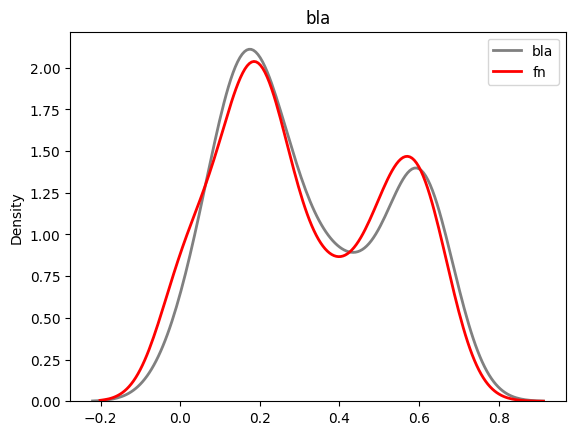

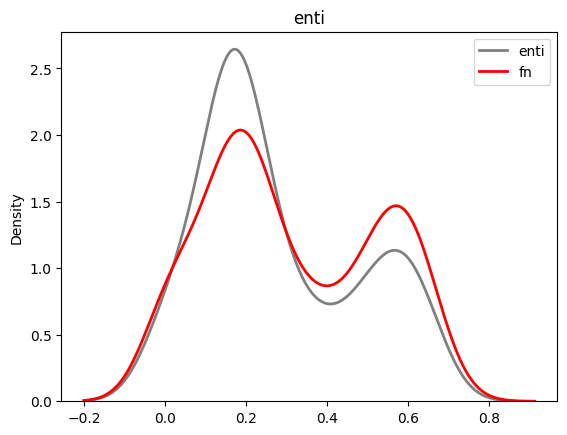

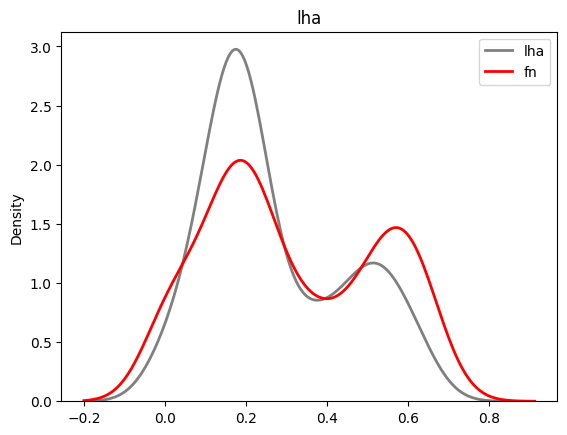

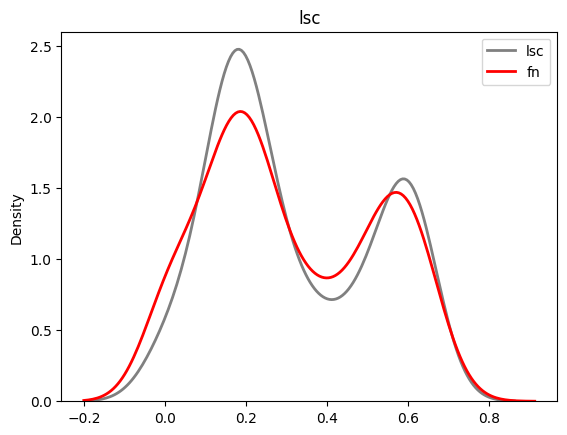

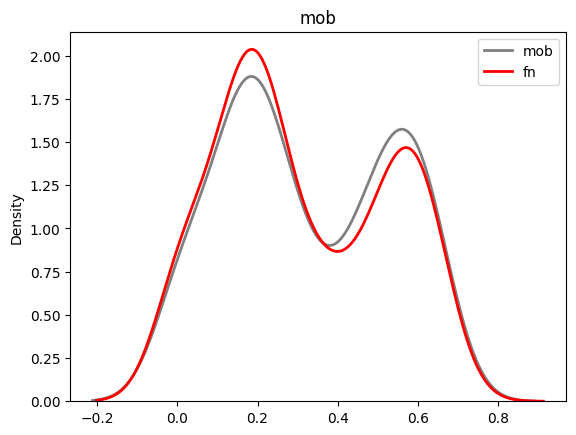

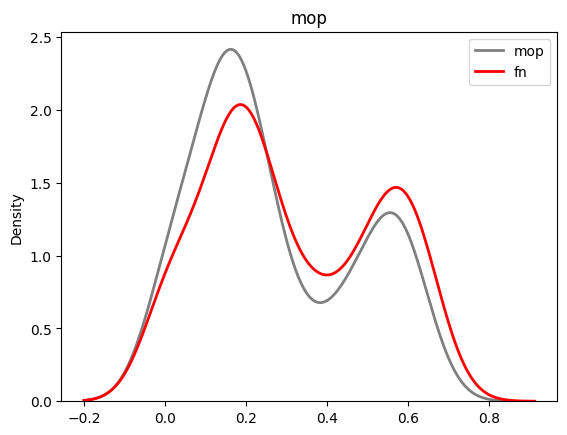

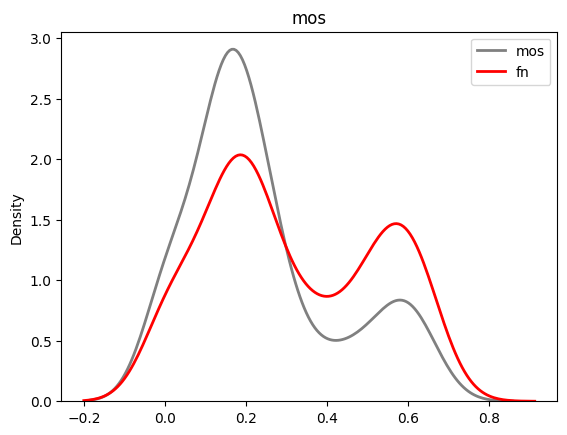

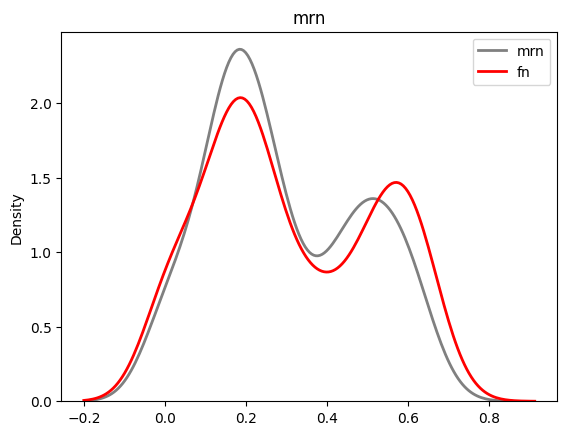

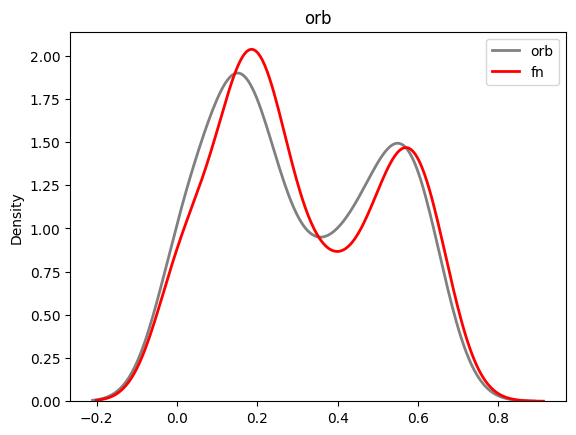

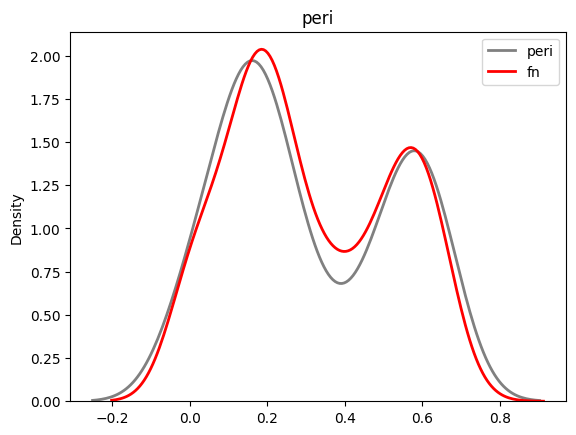

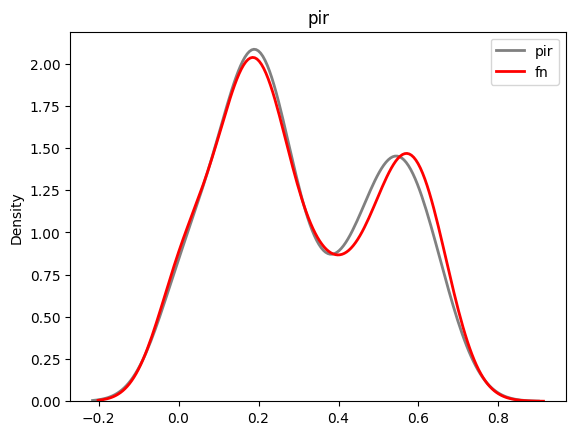

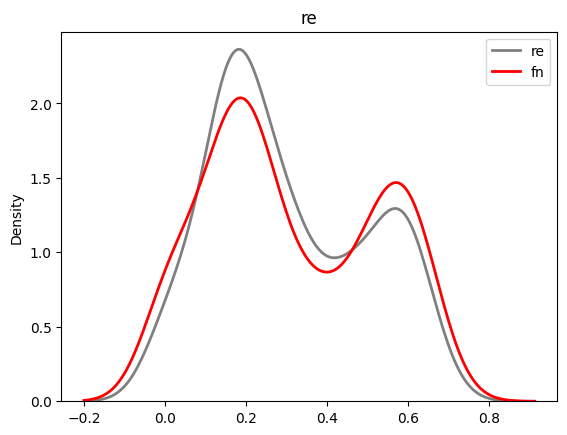

In [ ]:
# getting  transition coverage data
import seaborn as sns

nw = ['bla', 'enti', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']

for i in nw:
    a_data=reader.data_read_pkl(f'results/calculate_final_params/final_{i}.pkl')
    a_fcov=a_data[2]['cov']
    a_pcov=a_data[1]['cov']
    a_pcov=[x for x in a_pcov if x>0]
    a_cov=a_fcov+a_pcov

    
    plt.figure()
    sns.kdeplot(a_cov,color='grey',linewidth=2,label=i)
    fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
    fn_fcov=fn_data[2]['cov']
    fn_pcov=fn_data[1]['cov']
    fn_pcov=[x for x in fn_pcov if x>0]
    fn_cov=fn_fcov+fn_pcov
    sns.kdeplot(fn_cov,color='red',linewidth=2,label='fn')
    plt.title(i)
    plt.legend()
        




####  Take figure layout 

Text(0.05, 0.95, 'C')

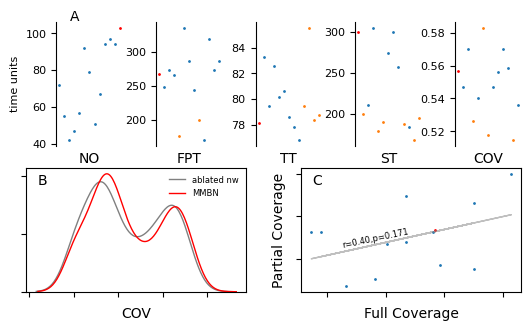

In [ ]:
fig=plt.figure(figsize=(6,3.5))
gs=gridspec.GridSpec(10,14,wspace=2.5,hspace=3) #10 rows, 15 columns

# fig 3A
# make 5 plots inside 
sub_gs=gs[0:5,:].subgridspec(1,5,wspace=0.5)

# number of transitions
ax0=fig.add_subplot(sub_gs[0])
ax0.set_xticks([]) # hide tick labels
ax0.tick_params(axis='y',labelsize=8)
ax0.set_xlabel('NO')
ax0.set_ylabel('time units',fontsize=8)

# ax0.scatter(np.arange(1,13),num_trans[1:],s=1)
# ax0.scatter(0,num_trans[0],c='Red',s=1)
x=np.linspace(0.5,0.18,13)
ax0.scatter(x[1:13],num_trans[1:],s=1)
ax0.scatter(x[0],num_trans[0],c='Red',s=1)
# Adjust subplot position (center it)
# pos = ax0.get_position()
# ax0.set_position([pos.x0, pos.y0, pos.width*0.4, pos.height])




#FPT
ax1=fig.add_subplot(sub_gs[1])
ax1.set_xticks([])
ax1.tick_params(axis='y',labelsize=8)
ax1.set_xlabel('FPT')
# not significant networks
n_sg_fpt=list(set(list(range(1,13)))-set(f_m_s))
y_nsgfpt=[fpt_mean[x] for x in n_sg_fpt]
ax1.scatter(n_sg_fpt,y_nsgfpt,s=1)
# dark significant nw
y_fpt=[fpt_mean[x] for x in f_m_s ]
ax1.scatter(f_m_s,y_fpt,s=1)
# plot FN
ax1.scatter(0,fpt_mean[0],c='Red',s=1)

# parts = ax1.violinplot(fpt_mean, positions=[1.5], widths=1.0, showmeans=False, showextrema=False, showmedians=False)

# # Style violin (faded background)
# for pc in parts['bodies']:
#     pc.set_facecolor('grey')
#     pc.set_alpha(0.2)
#     pc.set_edgecolor('none')

# # Adjust limits so scatter fits inside violin
# ax1.set_xlim(1, 3)





#TT
ax2=fig.add_subplot(sub_gs[2])
ax2.set_xticks([])
ax2.tick_params(axis='y',labelsize=8)
ax2.set_xlabel('TT')
# not significant networks
n_sg_tt=list(set(list(range(1,13)))-set(t_m_s))
y_nsgtt=[trans_time[x] for x in n_sg_tt]
ax2.scatter(n_sg_tt,y_nsgtt,s=1)
# dark significant nw
y_tt=[trans_time[x] for x in t_m_s ]
ax2.scatter(t_m_s,y_tt,s=1)
#plot FN
ax2.scatter(0,trans_time[0],c='Red',s=1)




#ST
ax3=fig.add_subplot(sub_gs[3])
ax3.set_xticks([])
ax3.tick_params(axis='y',labelsize=8)
ax3.set_xlabel('ST')
# not significant networks
n_sg_st=list(set(list(range(1,13)))-set(s_m_s))
y_nsgst=[st_mean[x] for x in n_sg_st]
ax3.scatter(n_sg_st,y_nsgst,s=1)
# dark significant nw
y_st=[st_mean[x] for x in s_m_s ]
ax3.scatter(s_m_s,y_st,s=1)
#plot FN
ax3.scatter(0,st_mean[0],c='Red',s=1)



#COV
ax4=fig.add_subplot(sub_gs[4])
ax4.set_xticks([])
ax4.tick_params(axis='y',labelsize=8)
ax4.set_xlabel('COV')
# not significant networks
n_sg_cv=list(set(list(range(1,13)))-set(c_m_s))
y_nsgcv=[cov[x] for x in n_sg_cv]
ax4.scatter(n_sg_cv,y_nsgcv,s=1)
# dark significant nw
y_cv=[cov[x] for x in c_m_s ]
ax4.scatter(c_m_s,y_cv,s=1)
#plot FN
ax4.scatter(0,cov[0],c='Red',s=1)


# hide spines
for ax in [ax0,ax1,ax2,ax3,ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)



#fig 3B
# plot coverage in comparison to FN
# choose network which looks cool
ax5=fig.add_subplot(gs[5:10,0:7])
ax5.set_yticklabels([])
ax5.set_xticklabels([])
ax5.set_xlabel("COV")
# shift this to left for more space
pos = ax5.get_position()
ax5.set_position([pos.x0-0.05,pos.y0,pos.width,pos.height])

# choosing ORB as it will look best
# combining coverage of both FN and ablated nw so that it looks bimodal
a_data=reader.data_read_pkl(f'results/calculate_final_params/final_orb.pkl')
a_fcov=a_data[2]['cov']
a_pcov=a_data[1]['cov']
a_pcov=[x for x in a_pcov if x>0]
a_cov=a_fcov+a_pcov
sns.kdeplot(a_cov,ax=ax5,color='grey',linewidth=1,label='ablated nw')
# read full network data
fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
fn_fcov=fn_data[2]['cov']
fn_pcov=fn_data[1]['cov']
fn_pcov=[x for x in fn_pcov if x>0]
fn_cov=fn_fcov+fn_pcov
sns.kdeplot(fn_cov,ax=ax5,color='red',linewidth=1,label='MMBN')
ax5.legend(loc="upper right",fontsize=6,frameon=False)
ax5.set_ylabel("")




#fig 3C
# scatter plot of avg partial and full transition coverage
ax6=fig.add_subplot(gs[5:10,7:14])
ax6.set_yticklabels([])
ax6.set_xticklabels([])
ax6.set_xlabel("Full Coverage")
ax6.set_ylabel("Partial Coverage")
ax6.scatter(cov[1:],cov_part[1:],s=1)
ax6.scatter(cov[0],cov_part[0],c='Red',s=1)
# fit straight line
coeffs=np.polyfit(cov,cov_part,deg=1)
slope,intercept=coeffs
y_fit=slope*np.array(cov)+intercept
#pearson correlation
corr,pval =pearsonr(cov,cov_part)
#plot fit line
ax6.plot(cov,y_fit,color='grey',linewidth=1, alpha=0.5)
# annotate over line
x_mid=np.mean(cov)
y_mid=slope*x_mid+intercept-0.006
angle=np.degrees(np.arctan(slope))-5
ax6.text(x_mid,y_mid,f"r={corr:.2f},p={pval:.3f}",
         fontsize=6,color='black', rotation=angle,
         ha="right",va="bottom")


# Add subplot labels inside boxes
ax0.text(0.2, 1.1, "A",
         transform=ax0.transAxes,
        
         va="top", ha="left",
         )

ax5.text(0.05, 0.95, "B",
         transform=ax5.transAxes,
         
         va="top", ha="left"
        )

ax6.text(0.05, 0.95, "C",
         transform=ax6.transAxes,
         
         va="top", ha="left"
         )



Significant networks in comparision to FN

FPT

In [98]:
f_m_l

['pir', 'enti']

ST

In [90]:
s_m_l

['lsc', 'orb', 'mrn', 're', 'lha', 'mop']

COV

In [100]:
c_m_l

['orb', 'bla', 'mrn', 'lha']

Transition time

In [101]:

t_m_l

['peri', 'mos', 'lha', 'mop']

# Figure 4
- use 'Analyse Cluster Backtrack.ipynb' notebook  
A. results/figures/fig4a_data.pkl  
B. results/figures/fig4b_data.pkl as dataframe 'bz2' compression  
C. results/figures/fig4c_data.pkl as dataframe 'bz2' compression  
D. results/figures/fig4d_data.pkl as dataframe 'bz2' compression  


Data for figure 4:  

C:\Users\NSharma\AppData\Local\Temp\ipykernel_9964\3616344210.py:78: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(df.columns,fontsize=8)


Text(0, 0.5, 'PCA 2')

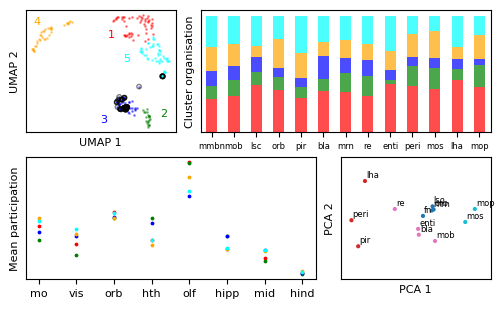

In [ ]:
fig=plt.figure(figsize=(6,3.5))
gs=gridspec.GridSpec(10,14,wspace=2.5,hspace=5) #10 rows, 14 columns

# 4A
# plot umap of FN
ax1=fig.add_subplot(gs[0:5,0:5])
ax1.set_xticks([])
ax1.set_yticks([])
colors = {0: "red", 1: "green", 2: "blue",3:"orange",4:"cyan"}
data_a=reader.data_read_pkl('results/figures/fig4a_data.pkl')
for cluster_id in np.unique(data_a['lbl']):
    cluster_points =data_a['we'][data_a['lbl'] == cluster_id]
    ax1.scatter(cluster_points[:,0], cluster_points[:,1],
                c=colors[cluster_id], s=1, alpha=0.4)

# jitter to full embeddings
x=data_a['fe'][:,0]
y=data_a['fe'][:,1]
# x_jitter = x + np.random.uniform(-0.1, 0.1, size=len(x))  # jitter in x
# y_jitter = y + np.random.uniform(-0.02, 0.02, size=len(y))  # jitter in y
ax1.scatter(x,y, 
            s=10,marker='o',facecolors='none',edgecolors='black',alpha=0.5)
ax1.set_xlabel('UMAP 1', fontsize=8)
ax1.set_ylabel('UMAP 2', fontsize=8)
# transform axis relative to figure
#label red cluster as 1
ax1.text(0.55, 0.8, "1",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='red')
#label green cluster as 2
ax1.text(0.9, 0.15, "2",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='green')
#label blue cluster as 3
ax1.text(0.5, 0.1, "3",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='blue')
#label orange cluster as 4
ax1.text(0.05, 0.9, "4",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='orange')
# label cyan cluster as 5
ax1.text(0.65, 0.6, "5",
        transform=ax1.transAxes, ha='left', va='center',fontsize=8,c='cyan')




#4B
# plot ratio of points in cluster to total points in cluster
ax2=fig.add_subplot(gs[0:5,5:14])
ax2.set_xticks([])
ax2.set_yticks([])
data_b=reader.data_read_bz2('results/figures/fig4b_data.pkl')
# reorder columns in ascending order of centrality 
des_order=network_asc.copy()
des_order[0]='mmbn'
#rename fn colimn name to mmbn
data_b=data_b.rename(columns={"fn": "mmbn"})
data_b_r=data_b[des_order]
data_b_r.T.plot(kind='bar',color=colors, stacked=True,ax=ax2,alpha=0.7,fontsize=8)
#turn legend off
ax2.legend().set_visible(False)
# set xlabels
ax2.set_xticklabels(data_b_r.columns, fontsize=6)
# set y label
ax2.set_ylabel('Cluster organisation', fontsize=8)



#4C
# plot mean participation across newtorks wrt community
ax3=fig.add_subplot(gs[5:10,0:9])

ax3.set_yticks([])
data_c = reader.data_read_pkl('results/figures/fig4c_data.pkl')
for i,df in enumerate(data_c,start=0):
     # Vertical mean (row-wise mean for each column)
    mean_vals = df.mean(axis=0)
    ax3.scatter(df.columns, mean_vals,s=3,
            color=colors[i], marker='o')
ax3.set_xticklabels(df.columns,fontsize=8)
ax3.set_ylabel('Mean participation',fontsize=8)




#4D
ax4=fig.add_subplot(gs[5:10,9:14])
ax4.set_xticks([])
ax4.set_yticks([])
# read data
data_d = reader.data_read_bz2('results/figures/fig4d_data.pkl')
nw_lbl = list(data_d.index)
#applying pca to reduce 13x40 to 13x2
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(data_d.values)
clu_tf_pca=reducer_pca.transform(data_d.values)
#apply kmeans
kmeans_pl = KMeans(n_clusters=4, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)
#scatter plot
ax4.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10',s=4)
for i, label in enumerate(nw_lbl):
    ax4.text(clu_tf_pca[i,0]+0.02, clu_tf_pca[i,1]+0.08, label, fontsize=6)
ax4.set_xlim(-1.5,1.5)
ax4.set_ylim(-1.5,1.5)
ax4.set_xlabel('PCA 1',fontsize=8)
ax4.set_ylabel('PCA 2',fontsize=8)

# ax4.text(0.3,0.5,'To be made')

# Figure 5

Use notebook 'Analyse Cluster Backtrack.ipynb'  
Data:  
5A: 'results/figures/fig5a_data.pkl'  
5B: 'results/figures/fig5b_data.pkl'  
5C: 'results/figures/fig5c_data.pkl'  
5BC1::'results/figures/fig5bc1_data.pkl'  
use notebook: 'Analyse Calculate Final Params.ipynb'  
5E: 'results/figures/fig5e_data.pkl'  
use notebook: 'Analyse Cluster Backtrack.ipynb'  
5F: 'results/figures/fig5f_data.pkl'  
use notebook: 'Analyse Calculate Final Params.ipynb'  
5H:'results/figures/fig5h_data.pkl'  
use notebook: 'Analyse Cluster Backtrack.ipynb'  
5I:'results/figures/fig5i_data.pkl'  
use notebook: 'Analyse fit fpt st error'  
5J:'results/figures/fig5j_data.pkl'  

Defining piecewise linear fit function for FPT and ST  
(reference notebook: 'Analyse Calculate Final Params.ipynb')

In [ ]:
def fit_st_fpt(data):
    intervals = data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    x = intervals
    y = log_ccdf
    # Fit piecewise linear model with 2 segments
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)
    return {'x':x,'y':y,'y_hat':y_hat}

 FIG 5E - T-statistic: 2.422, p-value: 3.219e-02
cluster3 : val1 [-0.028741361606189994, -0.04146605871074568, -0.028514966773508045, -0.0850968567754779, -0.022858389104726935, -0.0317514237202407, -0.028540897124730163, -0.029408840603287644, -0.04310469242259888, -0.03583123362455873, -0.035567968365189925, -0.03283448142140445],val2[-0.07267910786844164, -0.03220256748267529, -0.04224328854779097, -0.03855031201225124, -0.01570851028916618, -0.02248978959089124, -0.022434963732971786, -0.06838451480019449, -0.0123237731107319, -0.16582863471518788, -0.01193580590181362, -0.06649269687760773]


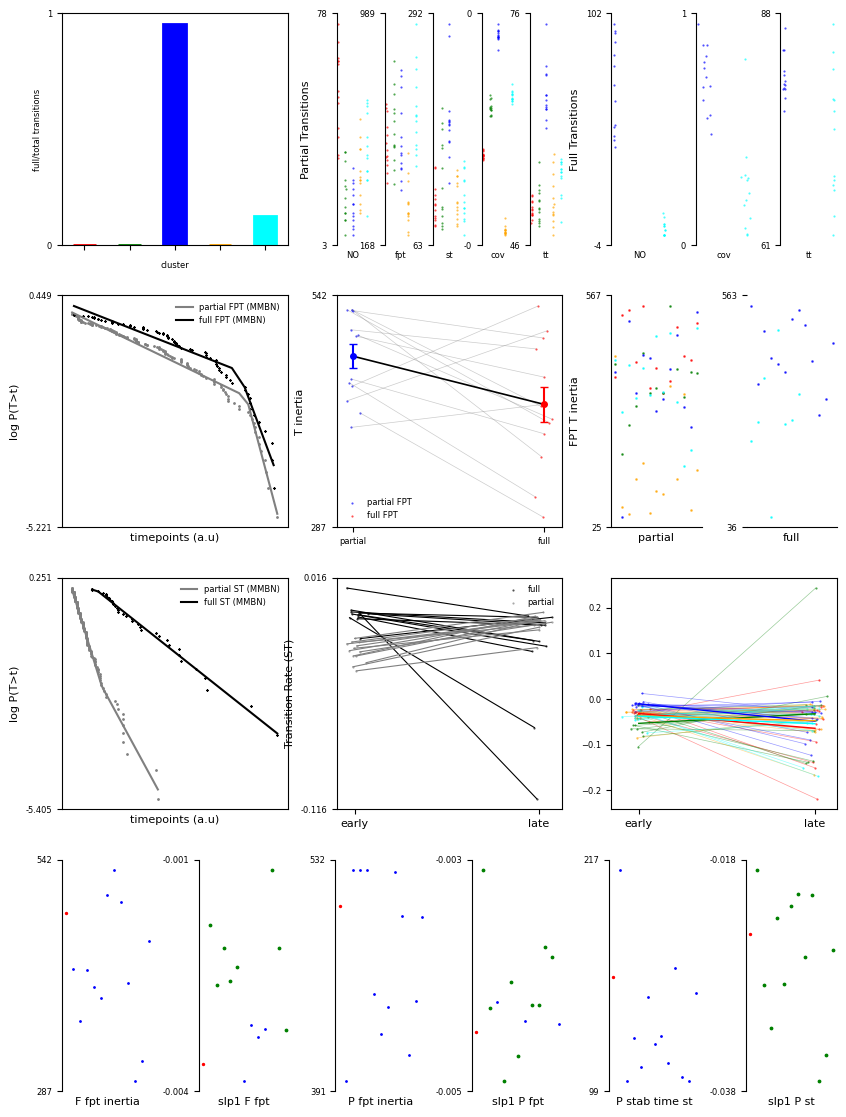

In [ ]:

fig=plt.figure(figsize=(10,14))
gs=gridspec.GridSpec(20,12,wspace=2.5,hspace=8) #10 rows, 14 columns

#5A
ax1=fig.add_subplot(gs[0:5,0:4])
colors=['red','green','blue','orange','cyan']
data_a=reader.data_read_bz2('results/figures/fig5a_data.pkl')
dt=data_a['fn']
dt.columns=[1,2,3,4,5]
dt.plot(kind='bar',color=colors,ax=ax1,fontsize=8,edgecolor=colors,linewidth=2)

# get current y limits
ymin, ymax = ax1.get_ylim()
# set ticks at first and last positions
ax1.set_yticks([ymin, ymax])
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax1.tick_params(axis='y', labelsize=6)
ax1.set_xticklabels([])
ax1.set_xlabel('cluster',fontsize=6)
ax1.set_ylabel('full/total transitions',fontsize=6)


#5B
data_5b=reader.data_read_pkl('results/figures/fig5b_data.pkl')
#make 5 plots inside this
# make 5 plots inside 
sub_gs=gs[0:5,4:8].subgridspec(1,5,wspace=0.5)
# to read clusters
cl=[0,1,2,3,4]

# number of transitions
ax2a=fig.add_subplot(sub_gs[0])
ax2a.set_xticks([])

# count number of transitions by counting number of transition time
data_5b1=reader.data_read_pkl('results/figures/fig5bc1_data.pkl')['5b1']
#scatter plot
for i,(key,values) in enumerate(data_5b1.items()):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(values))
    ax2a.scatter(jitter_x, values,color=colors[i], s=0.3, alpha=0.7, label=key)
ax2a.set_xlabel('NO',fontsize=6)
ax2a.set_ylabel('Partial Transitions',fontsize=8)
# get current y limits
ymin, ymax = ax2a.get_ylim()
# set ticks at first and last positions
ax2a.set_yticks([ymin, ymax])
ax2a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2a.tick_params(axis='y', labelsize=6)

#fpt
ax2b=fig.add_subplot(sub_gs[1])
ax2b.set_xticks([])
# get current y limits
ymin, ymax = ax2b.get_ylim()
# set ticks at first and last positions
ax2b.set_yticks([ymin, ymax])
ax2b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2b.tick_params(axis='y', labelsize=6)
# to append clusterwise all FPT
all_fpt=[]

colors=['red','green','blue','orange','cyan']
for i in cl:
    all_fpt.append(data_5b[i]['fpt'])
for i, cluster_vals in enumerate(all_fpt):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2b.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax2b.set_xlabel('fpt', fontsize=6)
# get current y limits
ymin, ymax = ax2b.get_ylim()
# set ticks at first and last positions
ax2b.set_yticks([ymin, ymax])
ax2b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2b.tick_params(axis='y', labelsize=6)

#st
ax2c=fig.add_subplot(sub_gs[2])
ax2c.set_xticks([])

all_st=[]
for i in cl:
    all_st.append(data_5b[i]['st'])
for i, cluster_vals in enumerate(all_st):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2c.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax2c.set_xlabel('st', fontsize=6)
# get current y limits
ymin, ymax = ax2c.get_ylim()
# set ticks at first and last positions
ax2c.set_yticks([ymin, ymax])
ax2c.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2c.tick_params(axis='y', labelsize=6)

#cov
ax2d=fig.add_subplot(sub_gs[3])
ax2d.set_xticks([])
# get current y limits
ymin, ymax = ax2d.get_ylim()
# set ticks at first and last positions
ax2d.set_yticks([ymin, ymax])
ax2d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2d.tick_params(axis='y', labelsize=6)
all_cov=[]
for i in cl:
    all_cov.append(data_5b[i]['cov'])
for i, cluster_vals in enumerate(all_cov):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2d.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax2d.set_xlabel('cov', fontsize=6)
# get current y limits
ymin, ymax = ax2d.get_ylim()
# set ticks at first and last positions
ax2d.set_yticks([ymin, ymax])
ax2d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2d.tick_params(axis='y', labelsize=6)

#tt
ax2e=fig.add_subplot(sub_gs[4])
ax2e.set_xticks([])
# get current y limits
ymin, ymax = ax2e.get_ylim()
# set ticks at first and last positions
ax2e.set_yticks([ymin, ymax])
ax2e.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2e.tick_params(axis='y', labelsize=6)
all_tt=[]
for i in cl:
    all_tt.append(data_5b[i]['tt'])
for i, cluster_vals in enumerate(all_tt):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax2e.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax2e.set_xlabel('tt', fontsize=6)
# get current y limits
ymin, ymax = ax2e.get_ylim()
# set ticks at first and last positions
ax2e.set_yticks([ymin, ymax])
ax2e.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax2e.tick_params(axis='y', labelsize=6)


# hide spines
for ax in [ax2a,ax2b,ax2c,ax2d,ax2e]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)



#5C
# adding 3 subplots
sub_gs=gs[0:5,8:12].subgridspec(1,3,wspace=0.5)
data_5c=reader.data_read_pkl('results/figures/fig5c_data.pkl')
cl=[2,4]
colors=['blue','cyan']
#NO
ax3a=fig.add_subplot(sub_gs[0])
ax3a.set_xticks([])

data_5c1=reader.data_read_pkl('results/figures/fig5bc1_data.pkl')['5c1']
#scatter plot
for i,(key,values) in enumerate(data_5c1.items()):
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(values))
    ax3a.scatter(jitter_x, values,color=colors[i], s=0.3, alpha=0.7, label=key)
ax3a.set_xlabel('NO',fontsize=6)
ax3a.set_ylabel('Full Transitions',fontsize=8)
# get current y limits
ymin, ymax = ax3a.get_ylim()
# set ticks at first and last positions
ax3a.set_yticks([ymin, ymax])
ax3a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax3a.tick_params(axis='y', labelsize=6)

#cov
ax3b=fig.add_subplot(sub_gs[1])
ax3b.set_xticks([])

all_cov=[]
for i in cl:
    all_cov.append(data_5c[i]['cov'])
for i, cluster_vals in enumerate(all_cov):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.07, size=len(cluster_vals))
    ax3b.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax3b.set_xlabel('cov', fontsize=6)
# get current y limits
ymin, ymax = ax3b.get_ylim()
# set ticks at first and last positions
ax3b.set_yticks([ymin, ymax])
ax3b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax3b.tick_params(axis='y', labelsize=6)

#tt
ax3c=fig.add_subplot(sub_gs[2])
ax3c.set_xticks([])

all_tt=[]
for i in cl:
    all_tt.append(data_5c[i]['tt'])
for i, cluster_vals in enumerate(all_tt):
    # jitter around the cluster index
    jitter_x = np.random.normal(loc=i, scale=0.01, size=len(cluster_vals))
    ax3c.scatter(jitter_x, cluster_vals, color=colors[i], s=0.3, alpha=0.7)
ax3c.set_xlabel('tt', fontsize=6)
# get current y limits
ymin, ymax = ax3c.get_ylim()
# set ticks at first and last positions
ax3c.set_yticks([ymin, ymax])
ax3c.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax3c.tick_params(axis='y', labelsize=6)


# hide spines
for ax in [ax3a,ax3b,ax3c]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)



#5D
# fpt fit plot for both partial and full FN transitions
ax4=fig.add_subplot(gs[5:10,0:4])
ax4.set_xticks([])

data_5d=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
data_pfn=data_5d[1]['fp_t']
data_ffn=data_5d[2]['fp_t']

# limit fpt in 20<x<600
data_pfn=[x for x in data_pfn if 20<x<600]
data_ffn=[x for x in data_ffn if 20<x<600]
# doing for partial transitions
params_pfn=fit_st_fpt(data_pfn)
ax4.scatter(params_pfn['x'],params_pfn['y'], s=1,c='gray')
ax4.plot(params_pfn['x'],params_pfn['y_hat'],'gray',label='partial FPT (MMBN)')
# doing for full transitions
params_ffn=fit_st_fpt(data_ffn)
ax4.scatter(params_ffn['x'],params_ffn['y'],s=1,c='k',marker='x')
ax4.plot(params_ffn['x'],params_ffn['y_hat'],'k',label='full FPT (MMBN)')
ax4.legend(fontsize=6,frameon=False)
# set up x and y labels
ax4.set_xlabel('timepoints (a.u)',fontsize=8)
ax4.set_ylabel('log P(T>t)',fontsize=8)
# get current y limits
ymin, ymax = ax4.get_ylim()
# set ticks at first and last positions
ax4.set_yticks([ymin, ymax])
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax4.tick_params(axis='y', labelsize=6)


#5E
ax5 = fig.add_subplot(gs[5:10,4:8])
data_5e = reader.data_read_pkl('results/figures/fig5e_data.pkl')
key1 = 'part_5d'
key2 = 'full_5d'
values1 = list(data_5e[key1].values())
values2 = list(data_5e[key2].values())
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax5.scatter(jitter_x1, values1, color='b', s=0.3, alpha=0.7,label='partial FPT')
ax5.scatter(jitter_x2, values2, color='r', s=0.3, alpha=0.7,label='full FPT')
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax5.plot([x1, x2], [y1, y2], color='gray', alpha=0.4, linewidth=0.5)
ax5.legend(frameon=False, fontsize=6)
# --- T-test ---
t_stat, p_val = scipy.stats.ttest_rel(values1, values2)  # paired t-test
print(f" FIG 5E - T-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")
# --- Means with error bars ---
mean1, mean2 = np.mean(values1), np.mean(values2)
sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
ax5.errorbar(0, mean1, yerr=sem1, fmt='o', color='blue', markersize=4, capsize=3)
ax5.errorbar(1, mean2, yerr=sem2, fmt='o', color='red', markersize=4, capsize=3)
# Line connecting the two means
ax5.plot([0, 1], [mean1, mean2], color='black', linewidth=1.2)
# set x and y labels
ax5.set_xticks([0,1])
ax5.set_xticklabels(['partial','full'],fontsize=6)
ax5.set_ylabel('T inertia',fontsize=8)
# get current y limits
ymin, ymax = ax5.get_ylim()
# set ticks at first and last positions
ax5.set_yticks([ymin, ymax])
ax5.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax5.tick_params(axis='y', labelsize=6)


#5F
# FPT clusterwise T inertia
sub_gs=gs[5:10,8:12].subgridspec(1,2,wspace=0.5)
#partial
ax6a=fig.add_subplot(sub_gs[0])
ax6a.set_xticks([])
data_6a=reader.data_read_pkl('results/figures/fig5f_data.pkl')['part_fpt_tin']
colors=['red','green','blue','orange','cyan']
for key,col in zip(data_6a.keys(),colors):
    values=data_6a[key]
    x=range(len(values))
    ax6a.scatter(x,values,color=col,alpha=0.7,s=0.8)
ax6a.set_xlabel('partial', fontsize=8)
ax6a.set_ylabel('FPT T inertia', fontsize=8)
# get current y limits
ymin, ymax = ax6a.get_ylim()
# set ticks at first and last positions
ax6a.set_yticks([ymin, ymax])
ax6a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax6a.tick_params(axis='y', labelsize=6)


#full
ax6b=fig.add_subplot(sub_gs[1])
data_6b=reader.data_read_pkl('results/figures/fig5f_data.pkl')['full_fpt_tin']
ax6b.set_xticks([])
ax6b.spines['left'].set_visible(False)
colors=['blue','cyan']
for key,col in zip(data_6b.keys(),colors):
    values=data_6b[key]
    x=range(len(values))
    ax6b.scatter(x,values,color=col,alpha=0.7,s=0.8)
ax6b.set_xlabel('full',fontsize=8)
# hide spines
for ax in [ax6a,ax6b]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
# get current y limits
ymin, ymax = ax6b.get_ylim()
# set ticks at first and last positions
ax6b.set_yticks([ymin, ymax])
ax6b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax6b.tick_params(axis='y', labelsize=6)



#5G
#st
ax7=fig.add_subplot(gs[10:15,0:4])
ax7.set_xticks([])
data_5f=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
data_pfn=data_5d[1]['s_t']
data_ffn=data_5d[2]['s_t']
# limit st in 25<x<800
data_pfn=[x for x in data_pfn if 25<x<800]
data_ffn=[x for x in data_ffn if 25<x<800]
# doing for partial transitions
params_pfn=fit_st_fpt(data_pfn)
ax7.scatter(params_pfn['x'],params_pfn['y'], s=1,c='gray')
ax7.plot(params_pfn['x'],params_pfn['y_hat'],'gray',label='partial ST (MMBN)')
# doing for full transitions
params_ffn=fit_st_fpt(data_ffn)
ax7.scatter(params_ffn['x'],params_ffn['y'],s=1,c='k',marker='x')
ax7.plot(params_ffn['x'],params_ffn['y_hat'],'k',label='full ST (MMBN)')
ax7.legend(fontsize=6,frameon=False)
# set up x and y labels
ax7.set_xlabel('timepoints (a.u)',fontsize=8)
ax7.set_ylabel('log P(T>t)',fontsize=8)
# get current y limits
ymin, ymax = ax7.get_ylim()
# set ticks at first and last positions
ax7.set_yticks([ymin, ymax])
ax7.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax7.tick_params(axis='y', labelsize=6)

#5H
# ST early and late
ax8=fig.add_subplot(gs[10:15,4:8])
ax8.set_xticks([])
data_5h = reader.data_read_pkl('results/figures/fig5h_data.pkl')

#plot full transition paired plot
# exclude 1st entry as it is outlier
values1 = data_5h['full']['early'][1:]
# values1.pop(-2)
# values1.pop(0)
values2 = data_5h['full']['late'][1:]
# values2.pop(-2)
# values2.pop(0)
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax8.scatter(jitter_x1, values1, color='k', s=0.3, alpha=0.7,label='full')
ax8.scatter(jitter_x2, values2, color='k', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax8.plot([x1, x2], [y1, y2], color='k', linewidth=0.8)

# plot partial transition paired plot
values1 = data_5h['part']['early']
values2 = data_5h['part']['late']
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax8.scatter(jitter_x1, values1, color='gray', s=0.3, alpha=0.7,label='partial')
ax8.scatter(jitter_x2, values2, color='gray', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax8.plot([x1, x2], [y1, y2], color='gray', linewidth=0.8)
ax8.legend(frameon=False, fontsize=6)
ax8.set_xticks([0,1])
ax8.set_xticklabels(['early','late'],fontsize=8)
ax8.set_ylabel('Transition Rate (ST)',fontsize=8)
# get current y limits
ymin, ymax = ax8.get_ylim()
# set ticks at first and last positions
ax8.set_yticks([ymin, ymax])
ax8.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax8.tick_params(axis='y', labelsize=6)


#5I
# removed data at index of cluster 2,3 and 4 as to restrict between -0.5 to 0.5 (see code)
ax9=fig.add_subplot(gs[10:15,8:12])
ax9.set_xticks([])
# ax9.set_yticks([])
data_5i=reader.data_read_pkl('results/figures/fig5i_data.pkl')

# plot for cluster 0
c=0
values1 = data_5i['early'][c]
values2 = data_5i['late'][c]
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax9.scatter(jitter_x1, values1, color='r', s=0.3, alpha=0.7)
ax9.scatter(jitter_x2, values2, color='r', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax9.plot([x1, x2], [y1, y2], color='red', alpha=0.4, linewidth=0.5)
# --- Means with error bars ---
mean1=np.mean(values1)
mean2=np.mean(values2)
# copying these values so that can plot mean on top
c0_m1=mean1.copy()
c0_m2=mean2.copy()
# sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
# ax9.errorbar(0, mean1, yerr=sem1, fmt='o', color='red', markersize=2, capsize=1.5)
# ax9.errorbar(1, mean2, yerr=sem2, fmt='o', color='red', markersize=2, capsize=1.5)
# Line connecting the two means
# ax9.plot([0, 1], [mean1, mean2], color='red', linewidth=1)

# plot for cluster 1
c=1
values1 = data_5i['early'][c]
values2 = data_5i['late'][c]
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax9.scatter(jitter_x1, values1, color='g', s=0.3, alpha=0.7)
ax9.scatter(jitter_x2, values2, color='g', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax9.plot([x1, x2], [y1, y2], color='green', alpha=0.4, linewidth=0.5)
# --- Means with error bars ---
mean1=np.mean(values1)
mean2=np.mean(values2)
# copying these values so that can plot mean on top
c1_m1=mean1.copy()
c1_m2=mean2.copy()
# sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
# ax9.errorbar(0, mean1, yerr=sem1, fmt='o', color='g', markersize=2, capsize=1.5)
# ax9.errorbar(1, mean2, yerr=sem2, fmt='o', color='g', markersize=2, capsize=1.5)
# Line connecting the two means
# ax9.plot([0, 1], [mean1, mean2], color='g', linewidth=1)

# plot for cluster 2
c=2
values1 = data_5i['early'][c]
#remove index 6 as it is outlier
values1.pop(6)
values2 = data_5i['late'][c]
values2.pop(6)
# print(f'cluster2 : val1 {values1},val2{values2}')
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax9.scatter(jitter_x1, values1, color='b', s=0.3, alpha=0.7)
ax9.scatter(jitter_x2, values2, color='b', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax9.plot([x1, x2], [y1, y2], color='b', alpha=0.4, linewidth=0.5)
# --- Means with error bars ---
mean1=np.mean(values1)
mean2=np.mean(values2)
# copying these values so that can plot mean on top
c2_m1=mean1.copy()
c2_m2=mean2.copy()
# sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
# ax9.errorbar(0, mean1, yerr=sem1, fmt='o', color='b', markersize=2, capsize=1.5)
# ax9.errorbar(1, mean2, yerr=sem2, fmt='o', color='b', markersize=2, capsize=1.5)
# Line connecting the two means
# ax9.plot([0, 1], [mean1, mean2], color='b', linewidth=1)

# plot for cluster 3
c=3
values1 = data_5i['early'][c]
#remove index 4
values1.pop(4)
values2 = data_5i['late'][c]
values2.pop(4)
print(f'cluster3 : val1 {values1},val2{values2}')
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax9.scatter(jitter_x1, values1, color='orange', s=0.3, alpha=0.7)
ax9.scatter(jitter_x2, values2, color='orange', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax9.plot([x1, x2], [y1, y2], color='orange', alpha=0.4, linewidth=0.5)
# --- Means with error bars ---
mean1=np.mean(values1)
mean2=np.mean(values2)
# copying these values so that can plot mean on top
c3_m1=mean1.copy()
c3_m2=mean2.copy()
# sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
# ax9.errorbar(0, mean1, yerr=sem1, fmt='o', color='orange', markersize=2, capsize=1.5)
# ax9.errorbar(1, mean2, yerr=sem2, fmt='o', color='orange', markersize=2, capsize=1.5)
# Line connecting the two means
# ax9.plot([0, 1], [mean1, mean2], color='orange', linewidth=1)

# plot for cluster 4
c=4
values1 = data_5i['early'][c]
# remove index 0
values1.pop(0)
values2 = data_5i['late'][c]
values2.pop(0)
# Jitter x positions
jitter_x1 = list(np.random.normal(loc=0, scale=0.03, size=len(values1)))
jitter_x2 = list(np.random.normal(loc=1, scale=0.03, size=len(values2)))
# Scatter plots
ax9.scatter(jitter_x1, values1, color='cyan', s=0.3, alpha=0.7)
ax9.scatter(jitter_x2, values2, color='cyan', s=0.3, alpha=0.7)
# Pairwise lines
for (x1, y1), (x2, y2) in zip(zip(jitter_x1, values1), zip(jitter_x2, values2)):
    ax9.plot([x1, x2], [y1, y2], color='cyan', alpha=0.4, linewidth=0.5)
# --- Means with error bars ---
mean1=np.mean(values1)
mean2=np.mean(values2)
# copying these values so that can plot mean on top
c4_m1=mean1.copy()
c4_m2=mean2.copy()
# sem1, sem2 = scipy.stats.sem(values1), scipy.stats.sem(values2)  # standard error of mean
# ax9.errorbar(0, mean1, yerr=sem1, fmt='o', color='cyan', markersize=2, capsize=1.5)
# ax9.errorbar(1, mean2, yerr=sem2, fmt='o', color='cyan', markersize=2, capsize=1.5)
# Line connecting the two means
# ax9.plot([0, 1], [mean1, mean2], color='cyan', linewidth=1)
# ax9.set_ylim([-0.5,1])
ax9.set_xticks([0,1])
ax9.set_xticklabels(['early','late'],fontsize=8)

# plotting mean lines
ax9.plot([0, 1], [c0_m1, c0_m2], color='r', linewidth=1)
ax9.plot([0, 1], [c1_m1, c1_m2], color='g', linewidth=1)
ax9.plot([0, 1], [c2_m1, c2_m2], color='b', linewidth=1)
ax9.plot([0, 1], [c3_m1, c3_m2], color='orange', linewidth=1)
ax9.plot([0, 1], [c4_m1, c4_m2], color='cyan', linewidth=1)
ax9.tick_params(axis='y', labelsize=6)

#5J
sub_gs=gs[15:20,0:12].subgridspec(1,6,wspace=0.5)
data_5j=reader.data_read_pkl('results/figures/fig5j_data.pkl')

#FPT inertia full
ax10a=fig.add_subplot(sub_gs[0])
ax10a.set_xticks([])
# ax10a.set_yticks([])
data_5ja=data_5j['fpt_full']['bp']
co=1
for k, v in data_5ja.items():
    if k != 'fn':
        # plot values for this key
        ax10a.scatter([co], v, s=1, c='b')
        co+=1
    else:
        # plot a single point for 'fn'
       ax10a.scatter([0], [v], s=2, c='r')
ax10a.set_xlabel('F fpt inertia',fontsize=8)
# get current y limits
ymin, ymax = ax10a.get_ylim()
# set ticks at first and last positions
ax10a.set_yticks([ymin, ymax])
ax10a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax10a.tick_params(axis='y', labelsize=6)


# FPT early slope full
ax10b=fig.add_subplot(sub_gs[1])
ax10b.set_xticks([])
data_5jb=data_5j['fpt_full']['slp1']
# list of significant nw
snw_jb=data_5j['fpt_full']['s_nw']
co=1
for k,v in data_5jb.items():
    if k in snw_jb:
        # significant nw
        ax10b.scatter([co],v,s=3,c='g')
        co+=1
    elif k=='fn':
        ax10b.scatter([0],[v],s=2,c='r')
    else:
        ax10b.scatter([co],v,s=1,c='b')
        co+=1
ax10b.set_xlabel('slp1 F fpt',fontsize=8)
# get current y limits
ymin, ymax = ax10b.get_ylim()
# set ticks at first and last positions
ax10b.set_yticks([ymin, ymax])
ax10b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax10b.tick_params(axis='y', labelsize=6)


#FPT inertia part
ax10c=fig.add_subplot(sub_gs[2])
ax10c.set_xticks([])
data_5jc=data_5j['fpt_part']['bp']
co=1
for k, v in data_5jc.items():
    if k != 'fn':
        # plot values for this key
        ax10c.scatter([co], v, s=1, c='b')
        co+=1
    else:
        # plot a single point for 'fn'
       ax10c.scatter([0], [v], s=2, c='r')
ax10c.set_xlabel('P fpt inertia',fontsize=8)
# get current y limits
ymin, ymax = ax10c.get_ylim()
# set ticks at first and last positions
ax10c.set_yticks([ymin, ymax])
ax10c.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax10c.tick_params(axis='y', labelsize=6)


#FPT early slope part
ax10d=fig.add_subplot(sub_gs[3])
ax10d.set_xticks([])
data_5jd=data_5j['fpt_part']['slp1']
snw_jd=data_5j['fpt_part']['s_nw']
co=1
for k,v in data_5jd.items():
    if k in snw_jd:
        # significant nw
        ax10d.scatter([co],v,s=3,c='g')
        co+=1
    elif k=='fn':
        ax10d.scatter([0],[v],s=2,c='r')
    else:
        ax10d.scatter([co],v,s=1,c='b')
        co+=1
ax10d.set_xlabel('slp1 P fpt',fontsize=8)
# get current y limits
ymin, ymax = ax10d.get_ylim()
# set ticks at first and last positions
ax10d.set_yticks([ymin, ymax])
ax10d.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax10d.tick_params(axis='y', labelsize=6)


#ST stab. time part
ax10e=fig.add_subplot(sub_gs[4])
ax10e.set_xticks([])
data_5je=data_5j['st_part']['bp']
co=1
for k, v in data_5je.items():
    if k != 'fn':
        # plot values for this key
        ax10e.scatter([co], v, s=1, c='b')
        co+=1
    else:
        # plot a single point for 'fn'
       ax10e.scatter([0], [v], s=2, c='r')
ax10e.set_xlabel('P stab time st',fontsize=8)
# get current y limits
ymin, ymax = ax10e.get_ylim()
# set ticks at first and last positions
ax10e.set_yticks([ymin, ymax])
ax10e.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# optionally format them (e.g. integers, smaller font)
ax10e.tick_params(axis='y', labelsize=6)



#ST early slope part
ax10f=fig.add_subplot(sub_gs[5])
ax10f.set_xticks([])
ax10f.set_yticks([])
data_5jf=data_5j['st_part']['slp1']
snw_jf=data_5j['st_part']['s_nw']
co=1
for k,v in data_5jf.items():
    if k in snw_jf:
        # significant nw
        ax10f.scatter([co],v,s=3,c='g')
        co+=1
    elif k=='fn':
        ax10f.scatter([0],[v],s=2,c='r')
    else:
        ax10f.scatter([co],v,s=1,c='b')
        co+=1
ax10f.set_xlabel('slp1 P st',fontsize=8)
# get current y limits
ymin, ymax = ax10f.get_ylim()
# set ticks at first and last positions
ax10f.set_yticks([ymin, ymax])
ax10f.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
# optionally format them (e.g. integers, smaller font)
ax10f.tick_params(axis='y', labelsize=6)



# hide spines
for ax in [ax10a,ax10b,ax10c,ax10d,ax10e,ax10f]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.savefig('../../data/results/figures/fig5d_.pdf',format='pdf')

#### ASIDE: finding index clusters (for fig5i) in which data exceeds the range

In [ ]:
data_5i=reader.data_read_pkl('results/figures/fig5i_data.pkl')
#early
indices=[i for i,x in enumerate(data_5i['early'][0]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['early'][1]) if  not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['early'][2]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['early'][3]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['early'][4]) if not -0.5<x<0.5]
print(indices)
#late
indices=[i for i,x in enumerate(data_5i['late'][0]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['late'][1]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['late'][2]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['late'][3]) if not -0.5<x<0.5]
print(indices)
indices=[i for i,x in enumerate(data_5i['late'][4]) if not -0.5<x<0.5]
print(indices)

# figure 6  
- Use 'df_data' from figure 3  for starting 7 rows

In [5]:
# in ascending order of betweenness centrality
network_asc = [
    "fn",
    "mob",
    "lsc",
    "orb",
    "pir",
    "bla",
    "mrn",
    "re",
    "enti",
    "peri",
    "mos",
    "lha",
    "mop",
]

# control node
control_node = [251, 38, 71, 284, 1, 214, 149, 362]
control_name = ["mob", "lsc", "mop", "mrn"]
cn=[1,2,6,12]
dict_cn=dict(zip(control_name,cn))

#rich club node
rich_club_node = [214, 1, 215, 2, 249, 36, 137, 350]
rich_club_node_name = ["mop", "mos", "peri", "lha"]
# removing peri as it is rich club
rc=[12,10,11]
dict_rc=dict(zip(rich_club_node_name,rc))

# important nodes
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["peri", "enti", "orb", "re", "bla", "pir"]
fi=[9,8,3,7,5,4]
dict_fi=dict(zip(imp_name,fi))

#important + rich club
dict_irc={'peri':9}

Making data for fig 6  

In [6]:
df_s7=df_data.copy()
df_s7

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  0.945461   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  0.865168   
orb        136   94  11.661904   9.695360  53.057721  1.124891  0.157965   
pir        110   67  10.488088   8.185353  54.763636  1.241981  0.522551   
bla        107   51  10.344080   7.141428  54.188318  1.117801  0.985780   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  0.254302   
re         200   92  14.142136   9.591663  54.124500  0.763217  0.836102   
enti       151   57  12.288206   7.549834  53.687417  0.960022  0.481269   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.010906   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.040213   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.041488   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.036977   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  0.945461  ...  0.104380  351.034483  47.294445   
lsc   79.419588  1.289129  0.865168  ...  0.986182  311.785714  68.102203   
orb   82.572340  1.616342  0.157965  ...  0.960917  347.413793  32.158404   
pir   80.195522  1.615760  0.522551  ...  0.040085  399.047619  67.131559   
bla   80.609804  1.689315  0.985780  ...  0.610470  230.625000  28.823784   
mrn   78.601899  1.529340  0.254302  ...  0.791234  407.600000  58.272546   
re    77.778261  1.304602  0.836102  ...  0.504608  487.000000  70.648425   
enti  76.766667  1.499051  0.481269  ...  0.410884  399.722222  54.870038   
peri  79.453191  1.495899  0.010906  ...  0.006671  253.333333  28.349668   
mos   85.559524  2.795582  0.040213  ...  0.324357  268.125000  29.287603   
lha   78.384545  1.645938  0.041488  ...  0.013377  358.000000  83.694683   
mop   78.736111  1.935845  0.036977  ...  0.927616  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   0.104380  0.167642  0.008659  0.750962  0.546801  0.007664  0.359165  
lsc   0.986182  0.186380  0.006779  0.348070  0.570075  0.006157  0.201947  
orb   0.960917  0.147165  0.008332  0.024119  0.526395  0.008266  0.009647  
pir   0.040085  0.167115  0.009095  0.737818  0.540389  0.008939  0.137276  
bla   0.610470  0.199997  0.010300  0.107743  0.582879  0.008483  0.028932  
mrn   0.791234  0.172446  0.007612  0.979731  0.518023  0.008323  0.000557  
re    0.504608  0.189600  0.007044  0.183253  0.546913  0.007366  0.338564  
enti  0.410884  0.172499  0.007728  0.775876  0.556293  0.008835  0.951700  
peri  0.006671  0.155180  0.010715  0.159732  0.570277  0.009150  0.288445  
mos   0.324357  0.156893  0.007194  0.120168  0.558530  0.010439  0.890791  
lha   0.013377  0.172548  0.006927  0.761627  0.514550  0.009643  0.000635  
mop   0.927616  0.150628  0.007123  0.041466  0.536189  0.007992  0.068637  

[13 rows x 28 columns]

1. Number of partial transitions  

In [7]:
# using poisson mean test  
mmbn_part=df_s7['num_trans']['part']['fn']
nepochs=40000

r_snw=[] # significant increase
b_snw=[] # significant decrease

r_nw=[] # insignificant increase
b_nw=[] # insignificant decrease

for nw in df_s7.index[1:]:
    s,p=scipy.stats.poisson_means_test(df_s7['num_trans']['part'][nw],nepochs,mmbn_part,nepochs)
    if p<0.05:
        if df_s7['num_trans']['part'][nw]>mmbn_part:
            r_snw.append(nw)
        else:
            b_snw.append(nw)
    
    else: # insignificant
        if df_s7['num_trans']['part'][nw]>mmbn_part:
            r_nw.append(nw)
        else:
            b_nw.append(nw)

no_p=[r_snw,b_snw,r_nw,b_nw]



2. Number of full transitions

In [8]:
mmbn_full=df_s7['num_trans']['full']['fn']
nepochs=40000

r_snw=[] # significant increase
b_snw=[] # significant decrease

r_nw=[] # insignificant increase
b_nw=[] # insignificant decrease

for nw in df_s7.index[1:]:
    s,p=scipy.stats.poisson_means_test(df_s7['num_trans']['full'][nw],nepochs,mmbn_full,nepochs)
    if p<0.05:
        if df_s7['num_trans']['full'][nw]>mmbn_full:
            r_snw.append(nw)
        else:
            b_snw.append(nw)
    
    else: # insignificant
        if df_s7['num_trans']['full'][nw]>mmbn_full:
            r_nw.append(nw)
        else:
            b_nw.append(nw)

no_f=[r_snw,b_snw,r_nw,b_nw]

3. Transition time partial

In [24]:
# we will check if p value by ManWhitney U test is < 0.05 for nw to be significant
mmbn_part=df_s7['trans_time']['part']['fn']

# list to store nw
r_snw=[]
b_snw=[]
r_nw=[]
b_nw=[]

for i,val in enumerate(df_s7['trans_time']['part_mw'][1:]):
	i+=1
	nw=df_s7.index[i]
	# check if significant
	if val < 0.05:
		# check if increase
		if df_s7['trans_time']['part'][nw] >mmbn_part:
			r_snw.append(nw)
		else:
			b_snw.append(nw)
	else:
		if df_s7['trans_time']['part'][nw] >mmbn_part:
			r_nw.append(nw)
		else:
			b_nw.append(nw)
		
tt_p=[r_snw,b_snw,r_nw,b_nw]

4. Transition Time Full

In [33]:
# we will check if p value by ManWhitney U test is < 0.05 for nw to be significant
mmbn_full=df_s7['trans_time']['full']['fn']

# list to store nw
r_snw=[]
b_snw=[]
r_nw=[]
b_nw=[]

for i,val in enumerate(df_s7['trans_time']['full_mw'][1:]):
	# skipping first FN value
	i+=1
	nw=df_s7.index[i]
	# check if significant
	if val < 0.05:
		# check if increase
		if df_s7['trans_time']['full'][nw] >mmbn_full:
			r_snw.append(nw)
		else:
			b_snw.append(nw)
	else:
		if df_s7['trans_time']['full'][nw] >mmbn_full:
			r_nw.append(nw)
		else:
			b_nw.append(nw)
		
tt_f=[r_snw,b_snw,r_nw,b_nw]

5. Coverage Partial

In [30]:
# we will check if p value by ManWhitney U test is < 0.05 for nw to be significant
mmbn_part=df_s7['cov']['part']['fn']

# list to store nw
r_snw=[]
b_snw=[]
r_nw=[]
b_nw=[]

for i,val in enumerate(df_s7['cov']['part_mw'][1:]):
	i+=1
	nw=df_s7.index[i]
	# check if significant
	if val < 0.05:
		# check if increase
		if df_s7['cov']['part'][nw] >mmbn_part:
			r_snw.append(nw)
		else:
			b_snw.append(nw)
	else:
		if df_s7['cov']['part'][nw] >mmbn_part:
			r_nw.append(nw)
		else:
			b_nw.append(nw)
		
cov_p=[r_snw,b_snw,r_nw,b_nw]

6. Coverage Full  
- NO full / NO part

In [34]:
# we will check if p value by ManWhitney U test is < 0.05 for nw to be significant
mmbn_full=df_s7['cov']['full']['fn']

# list to store nw
r_snw=[]
b_snw=[]
r_nw=[]
b_nw=[]

for i,val in enumerate(df_s7['cov']['full_mw'][1:]):
	# skipping first FN value
	i+=1
	nw=df_s7.index[i]
	# check if significant
	if val < 0.05:
		# check if increase
		if df_s7['cov']['full'][nw] >mmbn_full:
			r_snw.append(nw)
		else:
			b_snw.append(nw)
	else:
		if df_s7['cov']['full'][nw] >mmbn_full:
			r_nw.append(nw)
		else:
			b_nw.append(nw)
		
cov_f=[r_snw,b_snw,r_nw,b_nw]

7. Conversion ratio

In [18]:
def get_matrix_points(x,y):
    """Gives matrix points for fig 6

    Args:
        x (int): parameter index on Y axis (start from 1 and bottom left)
        y (list): list of nw

    Returns:
        list: matrix points i.e list of tuples (x,y,'o')
    """
    plot_key = {
    "mob":1,
    "lsc":2,
    "orb":3,
    "pir":4,
    "bla":5,
    "mrn":6,
    "re":7,
    "enti":8,
    "peri":9,
    "mos":10,
    "lha":11,
    "mop":12,
    "corr":13}
    mp=[]

    # dark if significant
    
    for v in y: # x is significant networks
        t=(x,plot_key[v],'o')
        mp.append(t)
    
    return mp

In [19]:
def draw_dots(nw_l,para,ax):  
    """draw dots for networks

    Args:
        nw_l (list): It contains list of significant and insigni nw [r_snw,b_snw,r_nw,b_nw]
        para (int): y axis parameter
        ax : plot axis
    """
    r_snw=nw_l[0]
    b_snw=nw_l[1]
    r_nw=nw_l[2]
    b_nw=nw_l[3]
    mp=get_matrix_points(para,b_snw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='blue',marker=marker,
                edgecolors='blue')

    mp=get_matrix_points(para,r_snw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='red',marker=marker,
                edgecolors='red')
        
    mp=get_matrix_points(para,b_nw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='none',marker=marker,
                edgecolors='blue')
        
    mp=get_matrix_points(para,r_nw)
    for r, c, marker in mp:
        ax.scatter(c, r, s=50, facecolors='none',marker=marker,
                edgecolors='red')

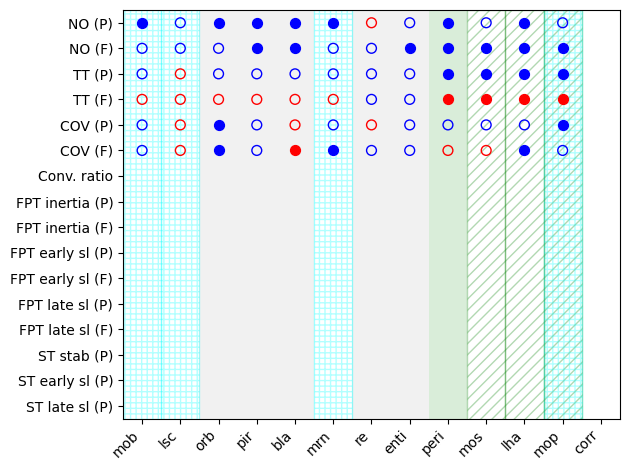

In [35]:
fig, ax = plt.subplots()

# Set up ticks and labels
ax.set_xticks(list(range(1,14)))
ax.set_xticklabels(["mob","lsc","orb","pir","bla","mrn","re","enti",
                    "peri","mos","lha","mop","corr"], 
                     rotation=45, ha='right')

ax.set_yticks(list(range(1,17)))
ax.set_yticklabels(['ST late sl (P)','ST early sl (P)','ST stab (P)',
                    'FPT late sl (F)','FPT late sl (P)',
                    'FPT early sl (F)','FPT early sl (P)',
                    'FPT inertia (F)','FPT inertia (P)',
                    'Conv. ratio','COV (F)','COV (P)','TT (F)',
                    'TT (P)','NO (F)','NO (P)'])

# shade green for rich club + functional important nodes  
for col in dict_irc.keys():
    ax.axvspan(dict_irc[col]-0.5, dict_irc[col]+0.5, facecolor='lightgreen', alpha=0.3)

# shade light grey for important nodes
for col in dict_fi.keys():
    ax.axvspan(dict_fi[col]-0.5, dict_fi[col]+0.5, facecolor='lightgrey', alpha=0.3)

# shade hatched green for rich club nodes
ymin, ymax = ax.get_ylim()  # full vertical span
for col in dict_rc.keys():
    rect = patches.Rectangle(
        (dict_rc[col]-0.5, ymin),        # bottom-left corner
        1.0,                             # width (one column)
        ymax - ymin+0.5,                     # height (full y-range)
        facecolor='none',                # no solid fill
        edgecolor='green',               # hatch color
        hatch='///',                     # hatch style
        alpha=0.3
    )
    ax.add_patch(rect)

# shade hatched cyan for control nodes
ymin, ymax = ax.get_ylim()  # full vertical span
for col in dict_cn.keys():
    rect = patches.Rectangle(
        (dict_cn[col]-0.5, ymin),        # bottom-left corner
        1.0,                             # width (one column)
        ymax - ymin+0.5,                 # height (full y-range)
        facecolor='none',                # no solid fill
        edgecolor='cyan',                # hatch color
        hatch='+++',                     # hatch style
        alpha=0.3
    )
    ax.add_patch(rect)

# NO part
draw_dots(no_p,16,ax=ax)

# NO full
draw_dots(no_f,15,ax=ax)

# TT (P)
draw_dots(tt_p,14,ax=ax)

# TT (F)
draw_dots(tt_f,13,ax=ax)

# COV (P)
draw_dots(cov_p,12,ax=ax)

# COV (F)
draw_dots(cov_f,11,ax=ax)


ax.set_xlim(0.5, 13.5)
ax.set_ylim(0.5, 16.5)
plt.tight_layout()
plt.show()


In [39]:
df_s7['cov']['part_mw']

fn      1.000000
mob     0.750962
lsc     0.348070
orb     0.024119
pir     0.737818
bla     0.107743
mrn     0.979731
re      0.183253
enti    0.775876
peri    0.159732
mos     0.120168
lha     0.761627
mop     0.041466
Name: part_mw, dtype: float64